# 01 — Dataset Exploration
This notebook loads the Augmented Alzheimer MRI Dataset and performs:
- Class distribution analysis
- Sample MRI image visualization
- Basic image stats (mean, std)

In [6]:
import sys
sys.path.insert(0, '..')  # Add project root to path
%matplotlib inline

import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from collections import Counter

from data.dataset_loader import AlzheimerMRIDataset, CLASS_NAMES, DEFAULT_CLASS_PROMPTS
from data.preprocessing import get_train_transform, get_val_transform, denormalize
from utils.config import load_config

print('Environment ready!')

Environment ready!


In [2]:
# Load config
cfg = load_config('../configs')
DATA_ROOT = os.path.join('..', cfg['paths']['data_root'])
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')
print(f'Train dir: {TRAIN_DIR}')
print(f'Test dir : {TEST_DIR}')

Train dir: ../data/raw/train
Test dir : ../data/raw/test


In [4]:
# ── 1. Class distribution ─────────────────────────────────────────
train_ds = AlzheimerMRIDataset(root_dir=TRAIN_DIR, transform=get_val_transform())
test_ds  = AlzheimerMRIDataset(root_dir=TEST_DIR,  transform=get_val_transform())

train_counts = Counter(lbl for _, _, lbl in train_ds)
test_counts  = Counter(lbl for _, _, lbl in test_ds)

print(f'Total train samples : {len(train_ds)}')
print(f'Total test  samples : {len(test_ds)}')
print()
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:25s} → Train: {train_counts[i]:4d}  |  Test: {test_counts[i]:4d}')

Total train samples : 33984
Total test  samples : 6400

  MildDemented              → Train: 8960  |  Test:  896
  ModerateDemented          → Train: 6464  |  Test:   64
  NonDemented               → Train: 9600  |  Test: 3200
  VeryMildDemented          → Train: 8960  |  Test: 2240


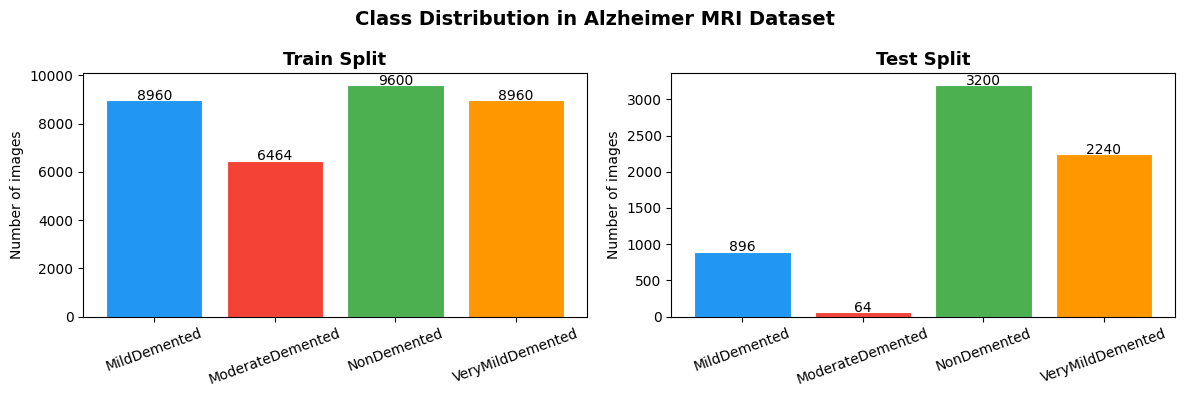

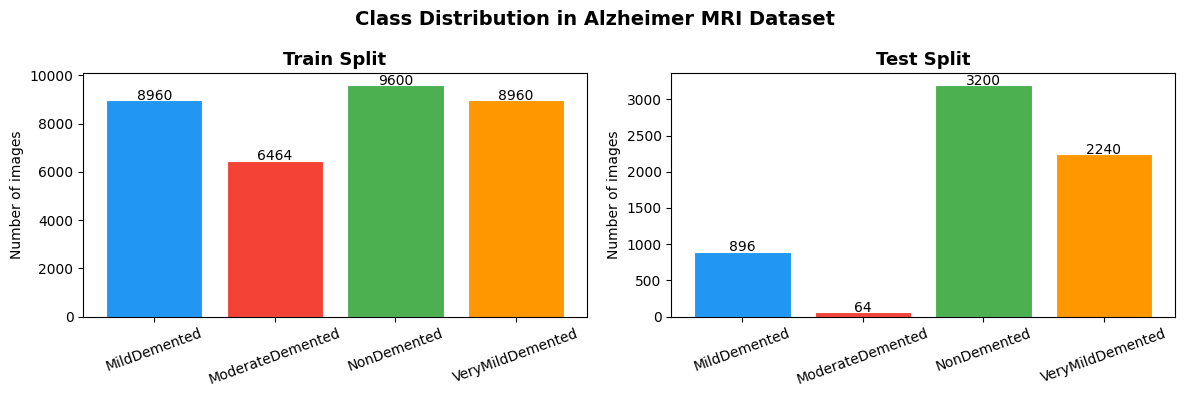

In [7]:
# ── 2. Bar chart of class distribution ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, counts, title in zip(axes, [train_counts, test_counts], ['Train Split', 'Test Split']):
    names  = CLASS_NAMES
    values = [counts[i] for i in range(len(names))]
    colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
    bars   = ax.bar(names, values, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of images')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontsize=10)

plt.suptitle('Class Distribution in Alzheimer MRI Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

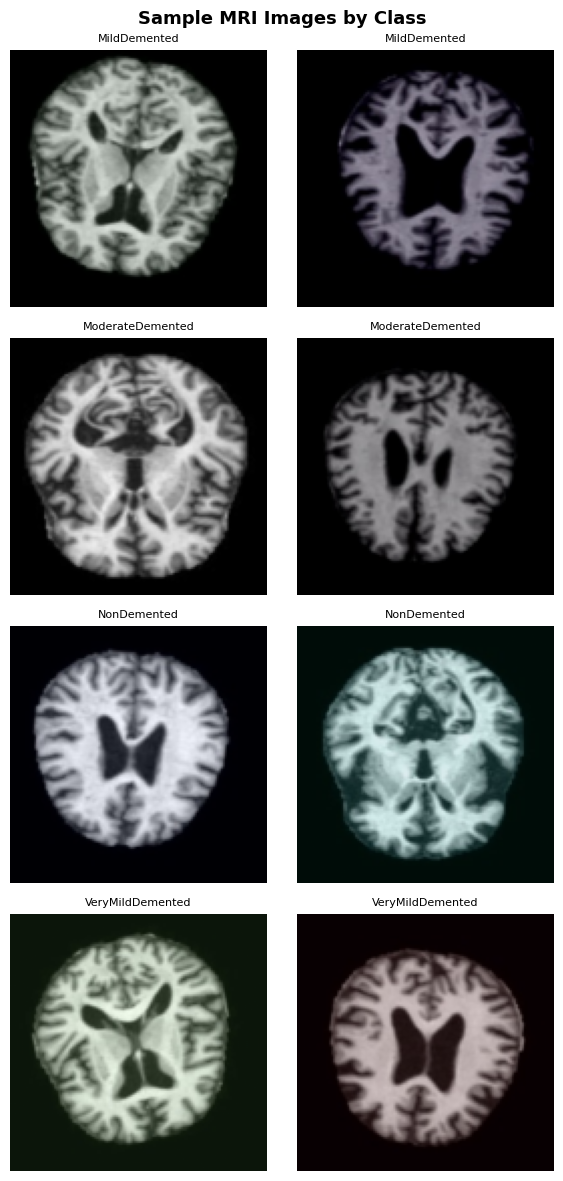

In [8]:
# ── 3. Sample MRI images (2 per class) ───────────────────────────
n_per_class = 2
fig, axes = plt.subplots(len(CLASS_NAMES), n_per_class, figsize=(n_per_class*3, len(CLASS_NAMES)*3))

shown = {i: 0 for i in range(len(CLASS_NAMES))}

for img_tensor, tokens, label in train_ds:
    if shown[label] < n_per_class:
        ax  = axes[label][shown[label]]
        img = denormalize(img_tensor).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(CLASS_NAMES[label], fontsize=8)
        ax.axis('off')
        shown[label] += 1
    if all(v >= n_per_class for v in shown.values()):
        break

plt.suptitle('Sample MRI Images by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── 4. Show text prompts ──────────────────────────────────────────
print('Text prompts used for vision-language alignment:\n')
for cls, prompt in DEFAULT_CLASS_PROMPTS.items():
    print(f'  [{cls}]\n  → {prompt}\n')

Text prompts used for vision-language alignment:

  [NonDemented]
  → This MRI shows no signs of dementia. The brain appears normal.

  [VeryMildDemented]
  → This MRI shows very mild dementia with minimal cognitive decline.

  [MildDemented]
  → This MRI shows mild dementia with noticeable cognitive impairment.

  [ModerateDemented]
  → This MRI shows moderate dementia with significant brain atrophy.



In [10]:
# ── 5. Image stats ────────────────────────────────────────────────
import torch
from torch.utils.data import DataLoader

loader    = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=0)
mean_acc  = torch.zeros(3)
std_acc   = torch.zeros(3)
n_batches = 0

for img_batch, _, _ in loader:
    mean_acc  += img_batch.mean(dim=[0, 2, 3])
    std_acc   += img_batch.std(dim=[0, 2, 3])
    n_batches += 1

mean_acc /= n_batches
std_acc  /= n_batches

print(f'Dataset mean (after norm): {mean_acc.tolist()}')
print(f'Dataset std  (after norm): {std_acc.tolist()}')

Dataset mean (after norm): [-0.827254056930542, -0.7163394093513489, -0.4906674325466156]
Dataset std  (after norm): [1.3782267570495605, 1.408990740776062, 1.402655005455017]
